# 🤖 Week 3 — Machine Learning
## Models Covered: KNN | SVM | Decision Tree

---

> **Prerequisites:** Python basics, NumPy, Pandas, Matplotlib, and Week 1–2 concepts (Linear & Logistic Regression).

### 📌 Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [K-Nearest Neighbors (KNN)](#2-k-nearest-neighbors-knn)
3. [Support Vector Machine (SVM)](#3-support-vector-machine-svm)
4. [Decision Tree](#4-decision-tree)
5. [Model Comparison](#5-model-comparison)
6. [🔥 Complex Tasks](#6-complex-tasks)


## 1. Setup & Imports

In [1]:
# ── Core libraries ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

# ── Sklearn datasets ──
from sklearn.datasets import load_iris, load_breast_cancer, make_classification, make_moons

# ── Preprocessing ──
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# ── Models ──
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# ── Metrics ──
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print(" All libraries imported successfully!")


 All libraries imported successfully!


---
## 2. K-Nearest Neighbors (KNN)

### 📖 What is KNN?
KNN is one of the **simplest** yet most powerful ML algorithms. It is a **lazy learner** — meaning it does **no explicit training**. Instead it memorises the entire dataset and makes predictions at query time.

### 🔍 How Does It Work? (Step-by-Step)

```
New Point ──► Calculate distance to ALL training points
          ──► Sort by distance (ascending)
          ──► Pick top-K nearest neighbours
          ──► Majority vote ──► Predicted Class
```

### 📐 Distance Metrics
| Metric | Formula | When to use |
|--------|---------|-------------|
| **Euclidean** | √Σ(xᵢ−yᵢ)² | Continuous features (most common) |
| **Manhattan** | Σ\|xᵢ−yᵢ\| | High-dimensional / grid data |
| **Minkowski** | (Σ\|xᵢ−yᵢ\|ᵖ)^(1/p) | General form (p=2 → Euclidean) |

### ⚙️ Key Hyperparameter — **K**
- **K too small (e.g. K=1):** Overfitting — sensitive to noise
- **K too large (e.g. K=100):** Underfitting — decision boundary too smooth
- **Best practice:** Try odd K values to avoid ties; use cross-validation

### ✅ Pros & ❌ Cons
| ✅ Pros | ❌ Cons |
|---------|---------|
| No training time | Slow prediction (O(n) per query) |
| Naturally multi-class | High memory usage |
| Simple & interpretable | Sensitive to irrelevant features |
| Non-linear boundaries | Needs feature scaling! |


In [2]:
# ════════════════════════════════════════════
#  KNN — Step 1: Understand Distance (Manual)
# ════════════════════════════════════════════

def euclidean_distance(p1, p2):
    """Manual Euclidean distance between two points"""
    return np.sqrt(np.sum((np.array(p1) - np.array(p2))**2))

# Example
A = [2, 3]
B = [5, 7]
print(f"Point A: {A}")
print(f"Point B: {B}")
print(f"Euclidean Distance: {euclidean_distance(A, B):.4f}")
print(f"(sklearn verification: {np.linalg.norm(np.array(A)-np.array(B)):.4f})")


Point A: [2, 3]
Point B: [5, 7]
Euclidean Distance: 5.0000
(sklearn verification: 5.0000)


In [3]:
# ════════════════════════════════════════════
#  KNN — Step 2: Manual KNN from Scratch
# ════════════════════════════════════════════

class KNN_Scratch:
    """KNN implementation from scratch to understand the internals"""

    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        # KNN is lazy — just store data!
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        # 1. Compute distances to all training points
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # 2. Get indices of K nearest neighbours
        k_indices = np.argsort(distances)[:self.k]

        # 3. Get their labels
        k_labels = self.y_train[k_indices]

        # 4. Majority vote
        from collections import Counter
        return Counter(k_labels).most_common(1)[0][0]


# ── Quick test on toy data ──
X_toy = np.array([[1,2],[2,3],[3,1],[6,5],[7,7],[8,6]])
y_toy = np.array([0, 0, 0, 1, 1, 1])

model_scratch = KNN_Scratch(k=3)
model_scratch.fit(X_toy, y_toy)

test_point = [[4, 4]]
pred = model_scratch.predict(test_point)
print(f"Test point {test_point[0]} → Predicted class: {pred[0]}")
print("(0 = Group A, 1 = Group B)")


Test point [4, 4] → Predicted class: 0
(0 = Group A, 1 = Group B)


In [4]:
# ════════════════════════════════════════════
#  KNN — Step 3: Real Dataset (Iris)
# ════════════════════════════════════════════

iris = load_iris()
X, y = iris.data, iris.target

# Feature scaling is CRITICAL for KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=" * 50)
print("       KNN CLASSIFICATION REPORT (Iris)")
print("=" * 50)
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")


       KNN CLASSIFICATION REPORT (Iris)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Overall Accuracy: 93.33%


Best K (via CV): 6  |  CV Accuracy: 96.67%


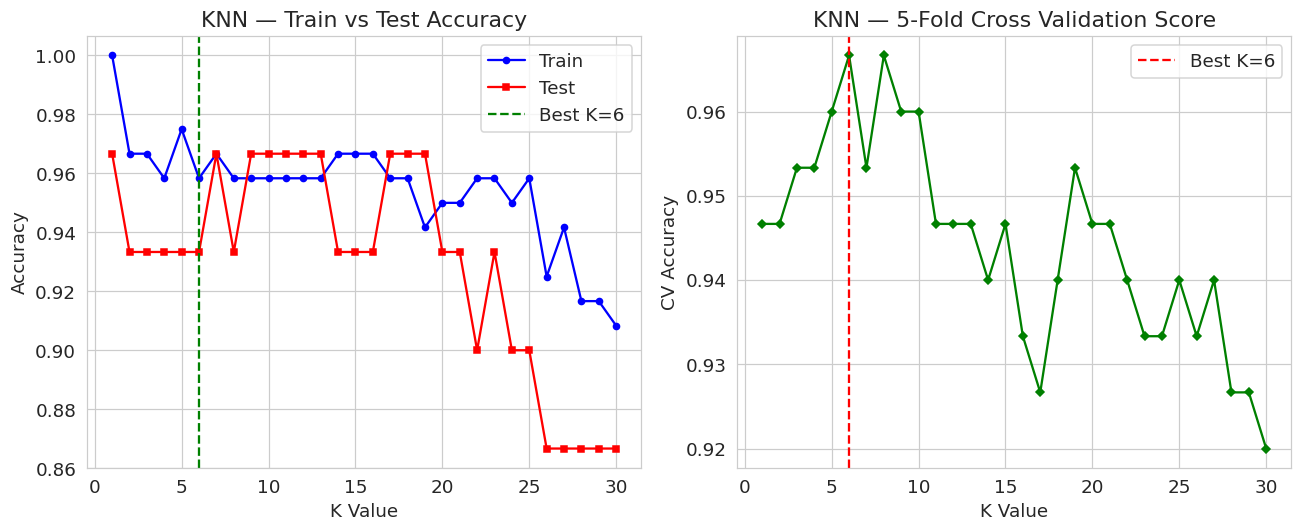

In [5]:
# ════════════════════════════════════════════
#  KNN — Step 4: Finding Optimal K
# ════════════════════════════════════════════

k_range = range(1, 31)
train_accuracies = []
test_accuracies  = []
cv_scores        = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, knn_k.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test,  knn_k.predict(X_test)))
    cv_scores.append(cross_val_score(knn_k, X_scaled, y, cv=5).mean())

best_k = k_range.start + np.argmax(cv_scores)
print(f"Best K (via CV): {best_k}  |  CV Accuracy: {max(cv_scores)*100:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, train_accuracies, 'b-o', ms=4, label='Train')
plt.plot(k_range, test_accuracies,  'r-s', ms=4, label='Test')
plt.axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value'); plt.ylabel('Accuracy')
plt.title('KNN — Train vs Test Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, cv_scores, 'g-D', ms=4)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K Value'); plt.ylabel('CV Accuracy')
plt.title('KNN — 5-Fold Cross Validation Score')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


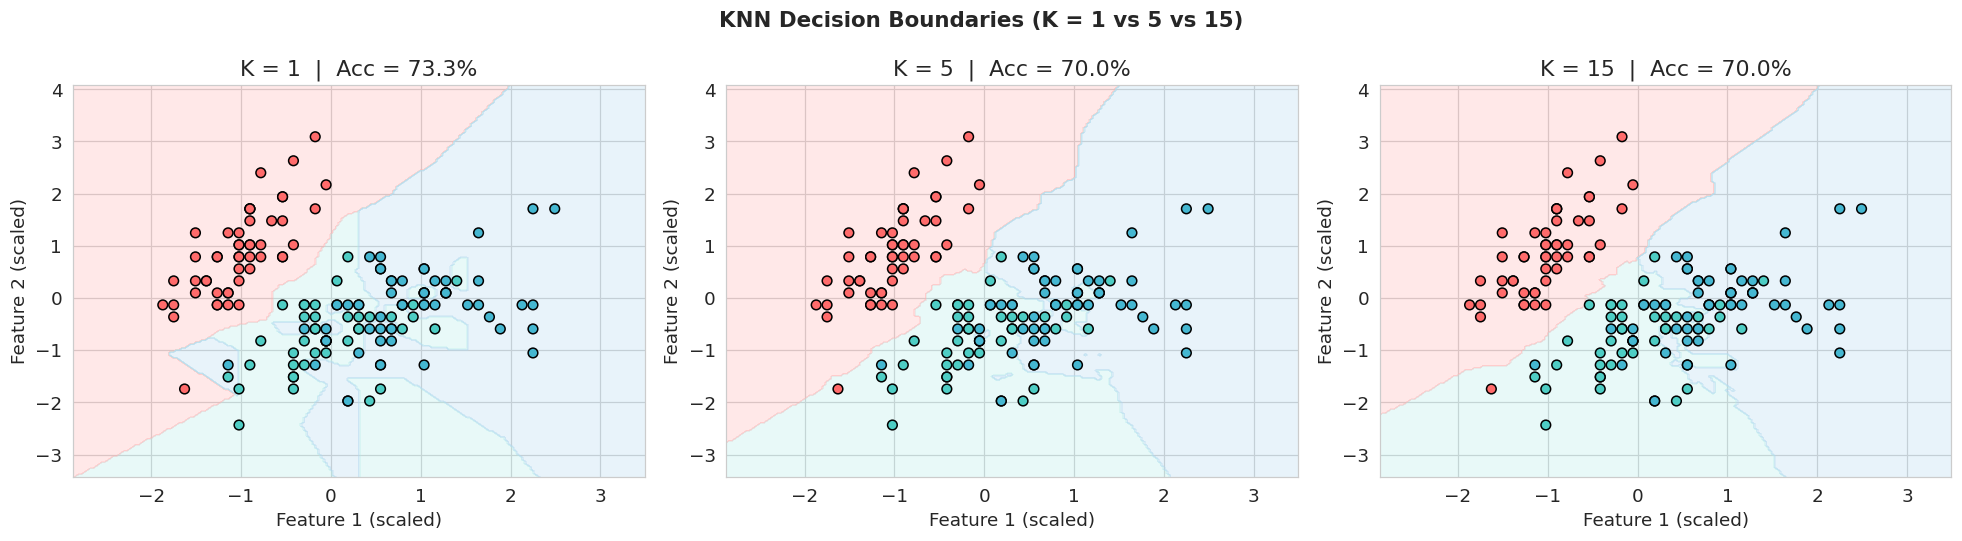


 Notice: K=1 → jagged boundaries (overfit), K=15 → smooth boundaries


In [6]:
# ════════════════════════════════════════════
#  KNN — Step 5: Decision Boundary Visualisation
# ════════════════════════════════════════════

# Use only 2 features for 2D visualisation
X2 = X_scaled[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_values = [1, 5, 15]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cmap_light = ListedColormap(['#FFB3B3', '#B3EDEA', '#B3D9F0'])
cmap_bold  = ListedColormap(colors)

for ax, k in zip(axes, k_values):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X2_train, y2_train)

    x_min, x_max = X2[:, 0].min()-1, X2[:, 0].max()+1
    y_min, y_max = X2[:, 1].min()-1, X2[:, 1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap=cmap_bold,
                         edgecolors='k', s=40)
    acc = accuracy_score(y2_test, clf.predict(X2_test))
    ax.set_title(f'K = {k}  |  Acc = {acc*100:.1f}%')
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')

plt.suptitle('KNN Decision Boundaries (K = 1 vs 5 vs 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Notice: K=1 → jagged boundaries (overfit), K=15 → smooth boundaries")


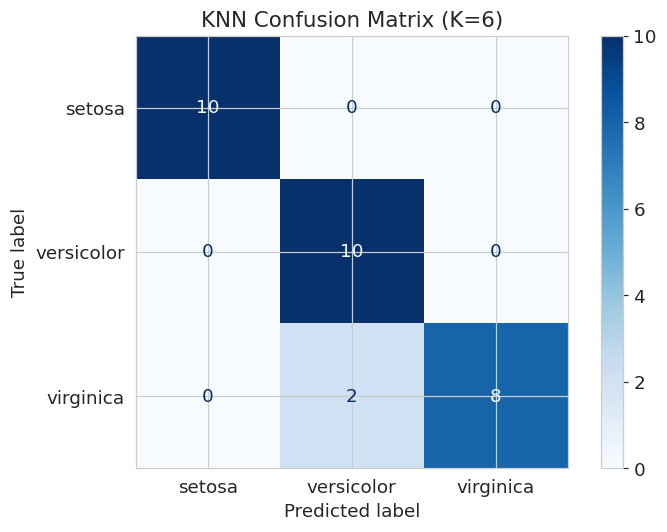


✅ Final KNN Accuracy (K=6): 93.33%


In [7]:
# ════════════════════════════════════════════
#  KNN — Step 6: Confusion Matrix
# ════════════════════════════════════════════

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred_best = best_knn.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=iris.target_names,
    cmap='Blues', ax=ax)
ax.set_title(f'KNN Confusion Matrix (K={best_k})', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✅ Final KNN Accuracy (K={best_k}): {accuracy_score(y_test, y_pred_best)*100:.2f}%")


---
## 3. Support Vector Machine (SVM)

### 📖 What is SVM?
SVM finds the **optimal hyperplane** that best separates two classes by **maximising the margin** between them. It's one of the most theoretically elegant algorithms in ML.

### 🔍 Core Concepts

#### 🎯 The Hyperplane
In 2D → a **line**. In 3D → a **plane**. In nD → a **hyperplane**.  
Equation: **w·x + b = 0**

#### 📏 Margin & Support Vectors
```
  Class -1          Margin          Class +1
  ●  ●                ↕               ○  ○
  ●      ←── w·x+b=-1  w·x+b=+1 ───►      ○
              [Support Vectors sit on these lines]
```
- **Margin** = 2 / ‖w‖ → SVM maximises this!
- **Support Vectors** = the data points closest to the hyperplane (they "support" / define it)

#### 🔧 The C Parameter (Regularisation)
| C value | Effect | Bias-Variance |
|---------|--------|---------------|
| Large C | Smaller margin, fewer misclassifications | Low bias, High variance |
| Small C | Larger margin, allows misclassifications | High bias, Low variance |

#### 🌀 The Kernel Trick
When data is **not linearly separable**, kernels map data to a **higher-dimensional space** where it becomes separable:

| Kernel | Formula | Use Case |
|--------|---------|---------|
| **Linear** | x·y | Linearly separable data |
| **RBF (Gaussian)** | exp(-γ‖x-y‖²) | Non-linear, most popular |
| **Polynomial** | (γx·y + r)ᵈ | Image classification |
| **Sigmoid** | tanh(γx·y + r) | Neural net-like behaviour |

### ✅ Pros & ❌ Cons
| ✅ Pros | ❌ Cons |
|---------|---------|
| Works well in high dimensions | Slow on large datasets |
| Effective when features > samples | Hard to interpret |
| Robust to outliers (max margin) | Sensitive to feature scaling |
| Kernel trick for non-linear data | C and γ tuning needed |


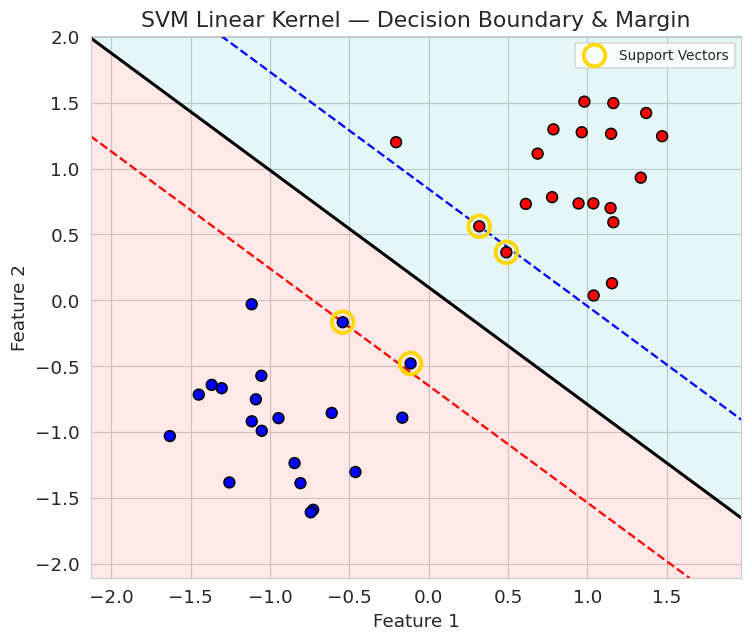


Number of Support Vectors: [2 2]
Support Vector counts per class: [2 2]


In [8]:
# ════════════════════════════════════════════
#  SVM — Step 1: Visualise the Margin Concept
# ════════════════════════════════════════════

np.random.seed(42)
# Linearly separable 2-class data
X_sv = np.r_[np.random.randn(20, 2) - [2, 2],
             np.random.randn(20, 2) + [2, 2]]
y_sv = np.array([0]*20 + [1]*20)

scaler_sv = StandardScaler()
X_sv_s = scaler_sv.fit_transform(X_sv)

svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_sv_s, y_sv)

# ── Plot decision boundary + margin ──
def plot_svm_boundary(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                alpha=0.15, colors=['#FF6B6B', '#4ECDC4'])
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               linestyles=['--', '-', '--'],
               colors=['red', 'black', 'blue'], linewidths=[1.5, 2, 1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolors='k', s=50, zorder=3)
    # Highlight support vectors
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none',
               edgecolors='gold', linewidths=2.5,
               label='Support Vectors', zorder=4)
    ax.set_title(title); ax.legend(fontsize=9)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm_boundary(svm_linear, X_sv_s, y_sv, ax,
                  'SVM Linear Kernel — Decision Boundary & Margin')
plt.tight_layout()
plt.show()
print(f"\nNumber of Support Vectors: {svm_linear.n_support_}")
print(f"Support Vector counts per class: {svm_linear.n_support_}")


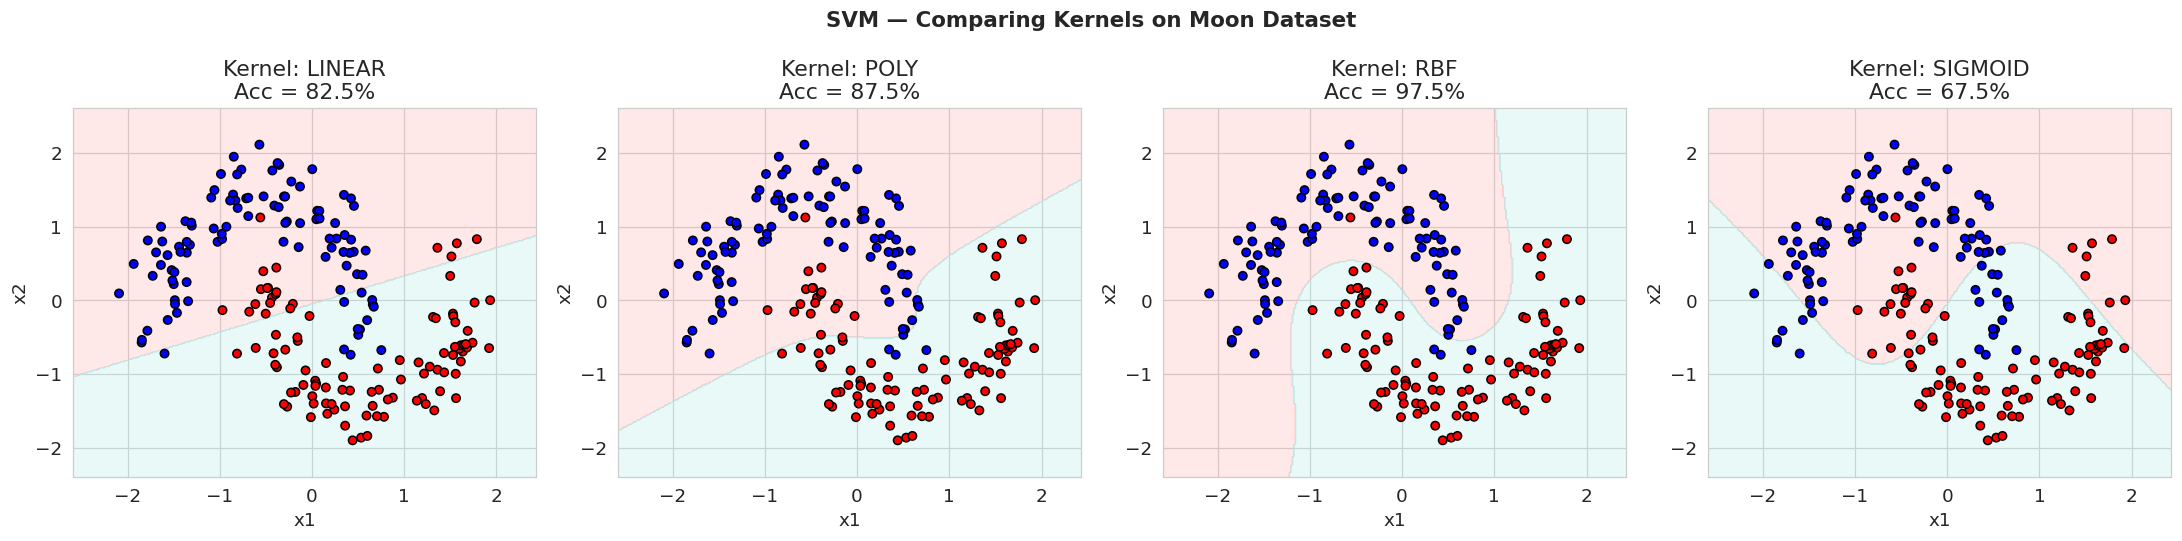

 RBF kernel handles non-linear data best!


In [9]:
# ════════════════════════════════════════════
#  SVM — Step 2: Kernel Trick on Non-Linear Data
# ════════════════════════════════════════════

X_moons, y_moons = make_moons(n_samples=200, noise=0.15, random_state=42)
X_moons_s = StandardScaler().fit_transform(X_moons)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_moons_s, y_moons, test_size=0.2, random_state=42)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, kernel in zip(axes, kernels):
    clf = SVC(kernel=kernel, C=1.0, gamma='scale')
    clf.fit(X_m_tr, y_m_tr)
    acc = accuracy_score(y_m_te, clf.predict(X_m_te))

    x_min, x_max = X_moons_s[:,0].min()-0.5, X_moons_s[:,0].max()+0.5
    y_min, y_max = X_moons_s[:,1].min()-0.5, X_moons_s[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFB3B3','#B3EDEA']))
    ax.scatter(X_moons_s[:,0], X_moons_s[:,1], c=y_moons,
               cmap='bwr', edgecolors='k', s=30)
    ax.set_title(f'Kernel: {kernel.upper()}\nAcc = {acc*100:.1f}%')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

plt.suptitle('SVM — Comparing Kernels on Moon Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" RBF kernel handles non-linear data best!")


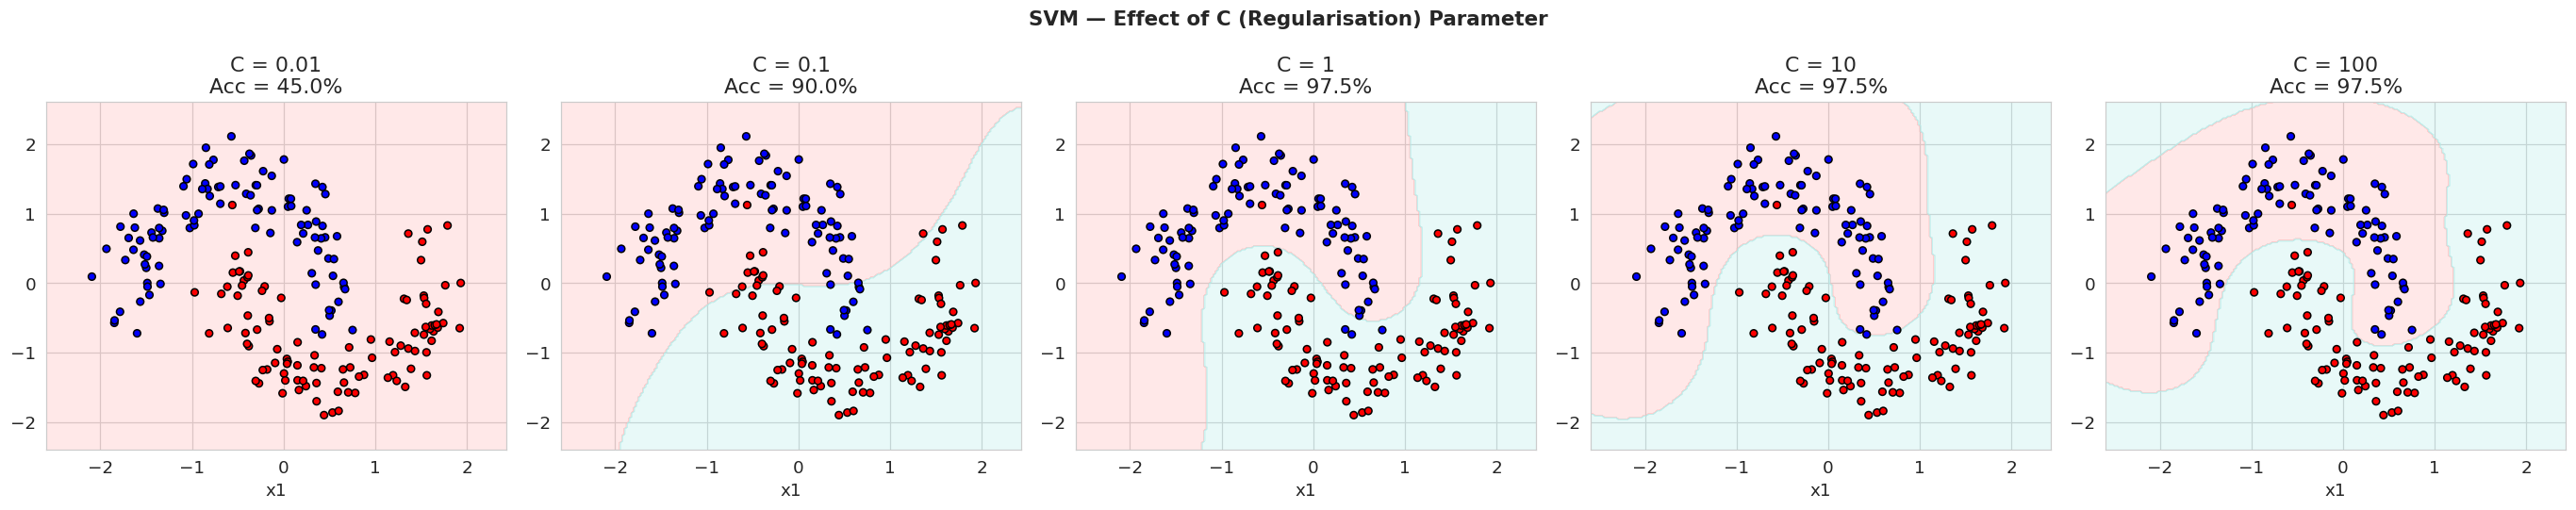

 Small C → smoother boundary (underfitting risk)
 Large C → complex boundary (overfitting risk)


In [10]:
# ════════════════════════════════════════════
#  SVM — Step 3: Effect of C Parameter
# ════════════════════════════════════════════

C_values = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, C in zip(axes, C_values):
    clf = SVC(kernel='rbf', C=C, gamma='scale')
    clf.fit(X_m_tr, y_m_tr)
    acc = accuracy_score(y_m_te, clf.predict(X_m_te))

    x_min, x_max = X_moons_s[:,0].min()-0.5, X_moons_s[:,0].max()+0.5
    y_min, y_max = X_moons_s[:,1].min()-0.5, X_moons_s[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFB3B3','#B3EDEA']))
    ax.scatter(X_moons_s[:,0], X_moons_s[:,1], c=y_moons,
               cmap='bwr', edgecolors='k', s=25)
    ax.set_title(f'C = {C}\nAcc = {acc*100:.1f}%')
    ax.set_xlabel('x1')

plt.suptitle('SVM — Effect of C (Regularisation) Parameter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Small C → smoother boundary (underfitting risk)")
print(" Large C → complex boundary (overfitting risk)")


Best Parameters: {'C': 10, 'gamma': 0.01}
Best CV Score:   98.02%

    SVM CLASSIFICATION REPORT (Breast Cancer)
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



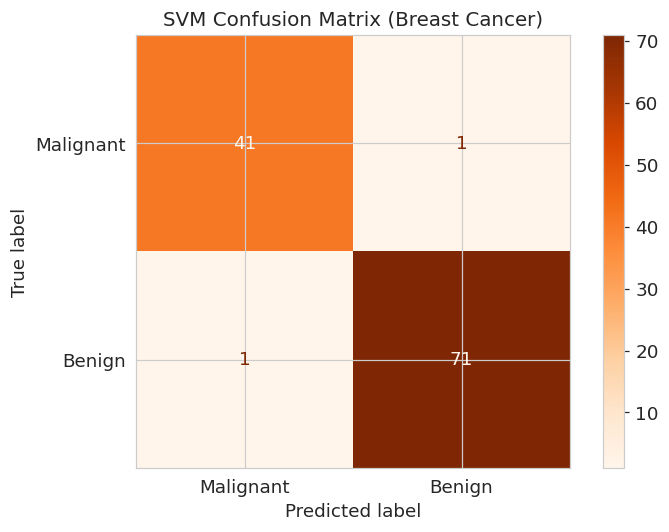

In [11]:
# ════════════════════════════════════════════
#  SVM — Step 4: Real Dataset + GridSearch
# ════════════════════════════════════════════

cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

X_c_scaled = StandardScaler().fit_transform(X_c)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_c_scaled, y_c, test_size=0.2, random_state=42, stratify=y_c)

# Grid Search for best C and gamma
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_c_tr, y_c_tr)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best CV Score:   {grid.best_score_*100:.2f}%")

best_svm = grid.best_estimator_
y_pred_svm = best_svm.predict(X_c_te)
print("\n" + "=" * 50)
print("    SVM CLASSIFICATION REPORT (Breast Cancer)")
print("=" * 50)
print(classification_report(y_c_te, y_pred_svm,
      target_names=['Malignant', 'Benign']))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_c_te, y_pred_svm,
    display_labels=['Malignant', 'Benign'],
    cmap='Oranges', ax=ax)
ax.set_title('SVM Confusion Matrix (Breast Cancer)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 4. Decision Tree

### 📖 What is a Decision Tree?
A Decision Tree is a **flowchart-like structure** that splits data by asking a series of questions. Each internal node tests a feature, each branch is an outcome, and each leaf is a prediction. It mimics **human decision-making**.

### 🔍 How Does It Work? (Splitting Criteria)

The algorithm greedily finds the **best feature + threshold** to split on at each node.

#### 📊 Gini Impurity
Measures how often a randomly chosen element would be **incorrectly labelled**:

**Gini = 1 − Σ pᵢ²**

- Gini = 0 → **Pure node** (all same class) ✅
- Gini = 0.5 → **Maximum impurity** (50/50 split) ❌

#### 📊 Entropy & Information Gain
**Entropy = − Σ pᵢ log₂(pᵢ)**

**Information Gain = Entropy(parent) − weighted avg Entropy(children)**

> The split with the **highest Information Gain** is chosen.

### 🌳 Tree Anatomy
```
         [Root Node: Petal length ≤ 2.45?]
              /                  \
           YES                    NO
      [Leaf: Setosa]     [Node: Petal width ≤ 1.75?]
                              /            \
                           YES              NO
                    [Leaf: Versicolor]  [Leaf: Virginica]
```

### ⚙️ Key Hyperparameters
| Parameter | What it controls |
|-----------|-----------------|
| `max_depth` | Maximum levels in the tree |
| `min_samples_split` | Min samples needed to split a node |
| `min_samples_leaf` | Min samples required in a leaf |
| `criterion` | 'gini' or 'entropy' |

### ✅ Pros & ❌ Cons
| ✅ Pros | ❌ Cons |
|---------|---------|
| Highly interpretable | Prone to overfitting |
| No feature scaling needed | Unstable (small data change → different tree) |
| Handles numeric & categorical | Biased toward high-cardinality features |
| Fast training & prediction | Not globally optimal (greedy splits) |


In [12]:
# ════════════════════════════════════════════
#  Decision Tree — Step 1: Manual Gini & Entropy
# ════════════════════════════════════════════

def gini_impurity(y):
    """Compute Gini impurity for an array of labels"""
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

def entropy(y):
    """Compute Entropy for an array of labels"""
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def information_gain(parent, left, right):
    """Information Gain from a split"""
    n = len(parent); nl = len(left); nr = len(right)
    return entropy(parent) - (nl/n * entropy(left) + nr/n * entropy(right))

# Demonstrate with example
y_parent = np.array([0,0,0,1,1,1,1,1])     # Mixed
y_left   = np.array([0,0,0])                # Pure (all class 0)
y_right  = np.array([1,1,1,1,1])            # Pure (all class 1)

print("=" * 45)
print("  Gini & Entropy Demo")
print("=" * 45)
print(f"Parent node  → Gini: {gini_impurity(y_parent):.4f}  | Entropy: {entropy(y_parent):.4f}")
print(f"Left child   → Gini: {gini_impurity(y_left):.4f}   | Entropy: {entropy(y_left):.4f}")
print(f"Right child  → Gini: {gini_impurity(y_right):.4f}   | Entropy: {entropy(y_right):.4f}")
print(f"\nInformation Gain: {information_gain(y_parent, y_left, y_right):.4f}")
print("\n IG = 0.954 means this was a PERFECT split!")


  Gini & Entropy Demo
Parent node  → Gini: 0.4688  | Entropy: 0.9544
Left child   → Gini: 0.0000   | Entropy: -0.0000
Right child  → Gini: 0.0000   | Entropy: -0.0000

Information Gain: 0.9544

 IG = 0.954 means this was a PERFECT split!


In [13]:
# ════════════════════════════════════════════
#  Decision Tree — Step 2: Train on Iris
# ════════════════════════════════════════════

iris = load_iris()
X_i, y_i = iris.data, iris.target
X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(
    X_i, y_i, test_size=0.2, random_state=42, stratify=y_i)

# Note: Decision Trees do NOT need feature scaling
dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(X_i_tr, y_i_tr)

y_pred_dt = dt.predict(X_i_te)
print("=" * 50)
print("  DECISION TREE CLASSIFICATION REPORT (Iris)")
print("=" * 50)
print(classification_report(y_i_te, y_pred_dt, target_names=iris.target_names))
print(f"Accuracy: {accuracy_score(y_i_te, y_pred_dt)*100:.2f}%")


  DECISION TREE CLASSIFICATION REPORT (Iris)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy: 96.67%


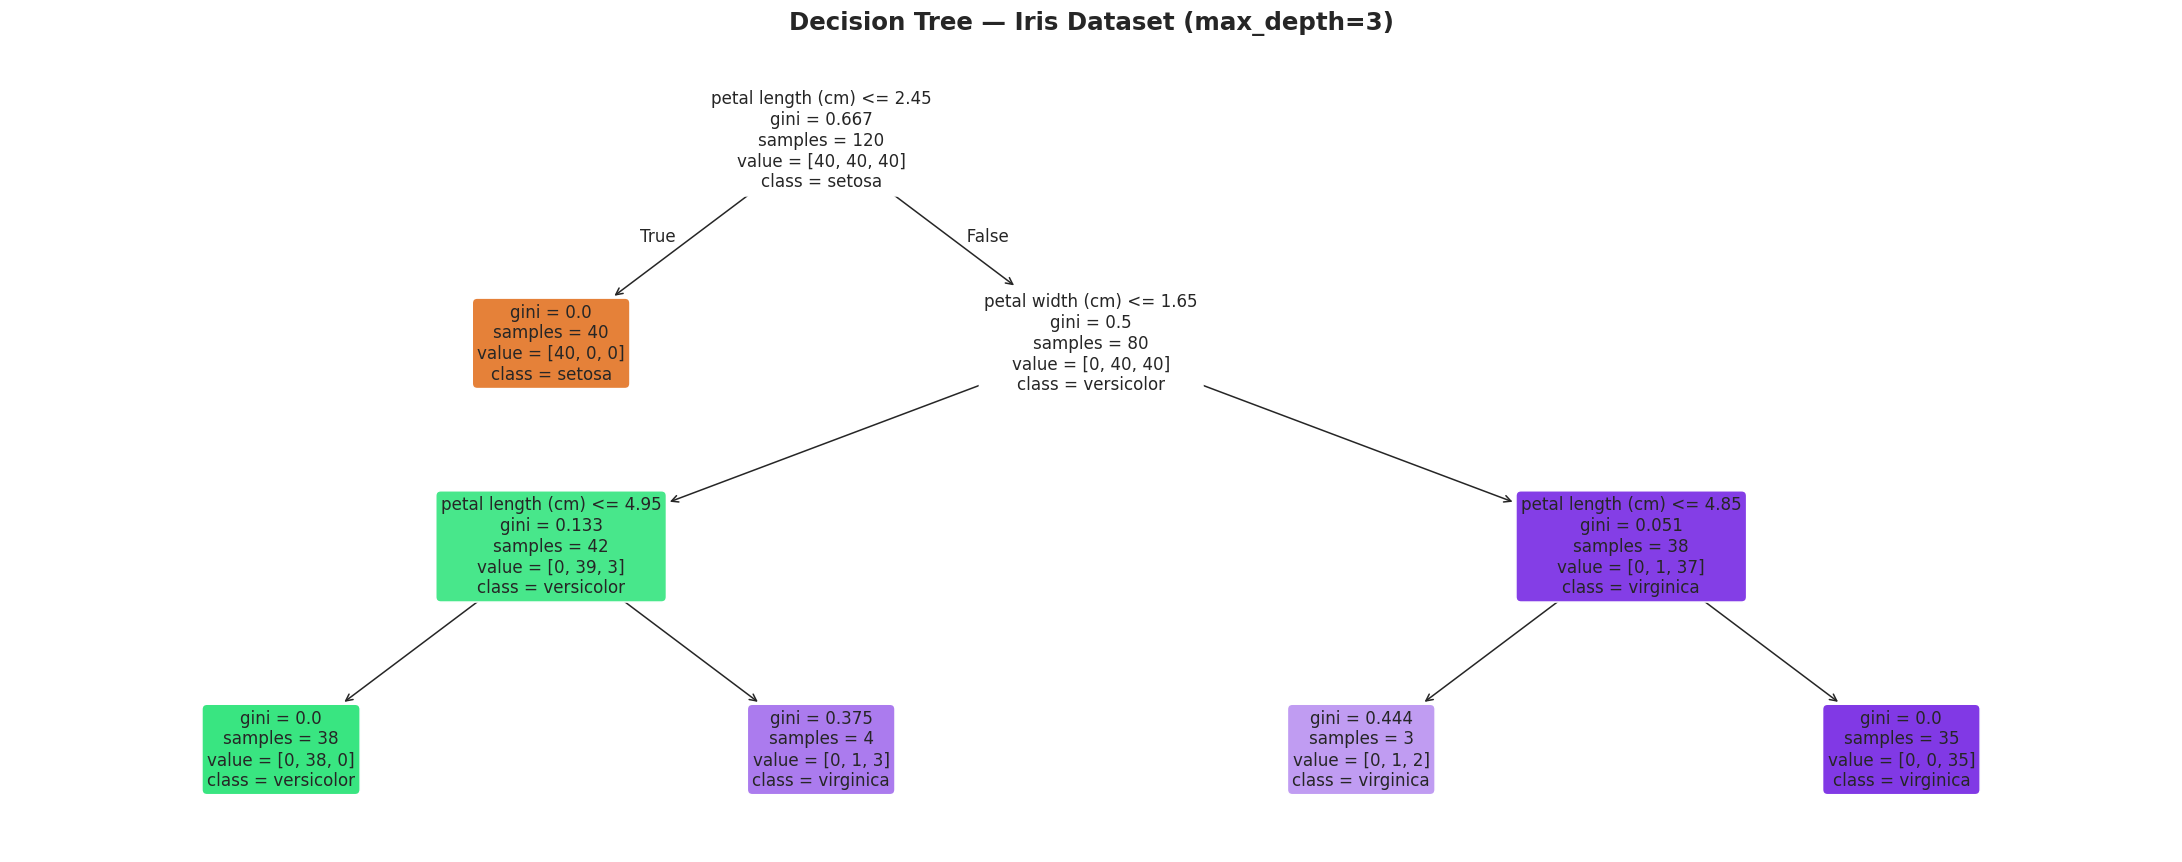


Text Representation of the Tree:
────────────────────────────────────────────────────────────
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.65
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.65
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [14]:
# ════════════════════════════════════════════
#  Decision Tree — Step 3: Visualise the Tree
# ════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True,
          fontsize=11, ax=ax,
          impurity=True, proportion=False)
plt.title('Decision Tree — Iris Dataset (max_depth=3)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Text representation
print("\nText Representation of the Tree:")
print("─" * 60)
print(export_text(dt, feature_names=list(iris.feature_names)))


Best max_depth: 3  |  Test Accuracy: 96.67%


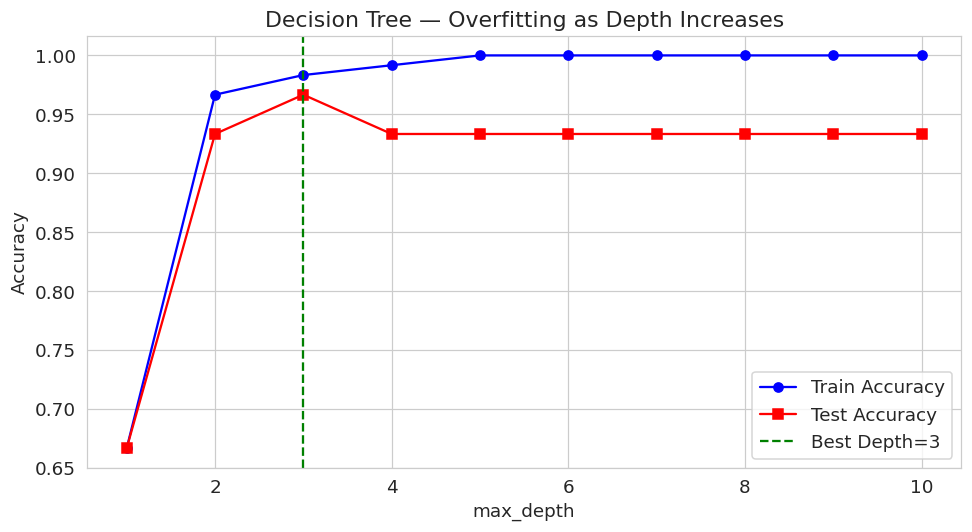


 High depth → train ≈ 1.0 but test drops → overfitting!


In [15]:
# ════════════════════════════════════════════
#  Decision Tree — Step 4: Effect of max_depth
# ════════════════════════════════════════════

depths = range(1, 11)
train_acc, test_acc = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_i_tr, y_i_tr)
    train_acc.append(accuracy_score(y_i_tr, clf.predict(X_i_tr)))
    test_acc.append(accuracy_score(y_i_te,  clf.predict(X_i_te)))

best_depth = depths.start + np.argmax(test_acc)
print(f"Best max_depth: {best_depth}  |  Test Accuracy: {max(test_acc)*100:.2f}%")

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'b-o', ms=6, label='Train Accuracy')
plt.plot(depths, test_acc,  'r-s', ms=6, label='Test Accuracy')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Best Depth={best_depth}')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree — Overfitting as Depth Increases')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()
print("\n High depth → train ≈ 1.0 but test drops → overfitting!")


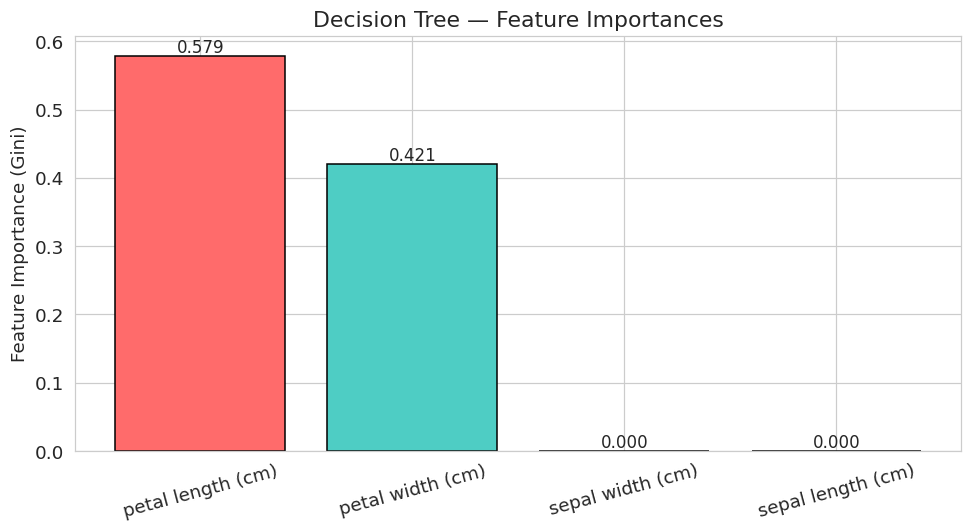


 Petal features are far more important than sepal features!


In [16]:
# ════════════════════════════════════════════
#  Decision Tree — Step 5: Feature Importance
# ════════════════════════════════════════════

importances = dt.feature_importances_
feat_names  = iris.feature_names
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 5))
bars = plt.bar(range(len(feat_names)),
               importances[indices],
               color=['#FF6B6B','#4ECDC4','#45B7D1','#FFA07A'],
               edgecolor='black')
plt.xticks(range(len(feat_names)),
           [feat_names[i] for i in indices], rotation=15)
plt.ylabel('Feature Importance (Gini)')
plt.title('Decision Tree — Feature Importances')
for bar, imp in zip(bars, importances[indices]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{imp:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print("\n Petal features are far more important than sepal features!")


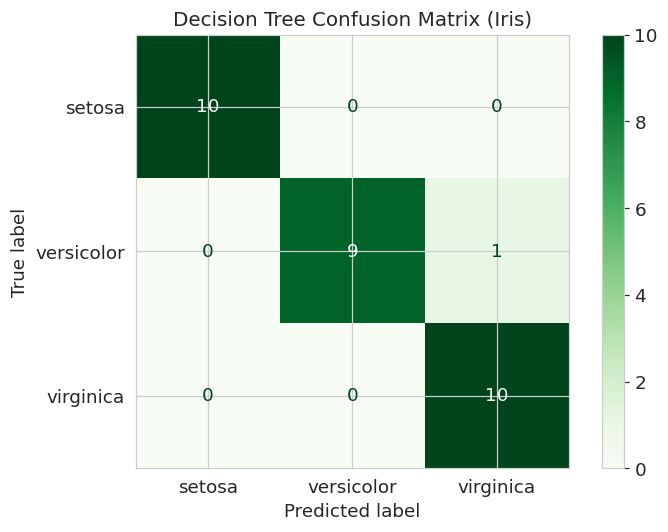

In [17]:
# ════════════════════════════════════════════
#  Decision Tree — Step 6: Confusion Matrix
# ════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_i_te, y_pred_dt,
    display_labels=iris.target_names,
    cmap='Greens', ax=ax)
ax.set_title('Decision Tree Confusion Matrix (Iris)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 5. Model Comparison

Let's compare all 3 models side-by-side on the same dataset.

Model                   Train Acc   Test Acc  CV (5-fold)
──────────────────────────────────────────────────────────
KNN (K=5)                  97.50%     93.33%       96.00%
SVM (RBF)                  97.50%     96.67%       96.67%
Decision Tree              98.33%     96.67%       97.33%


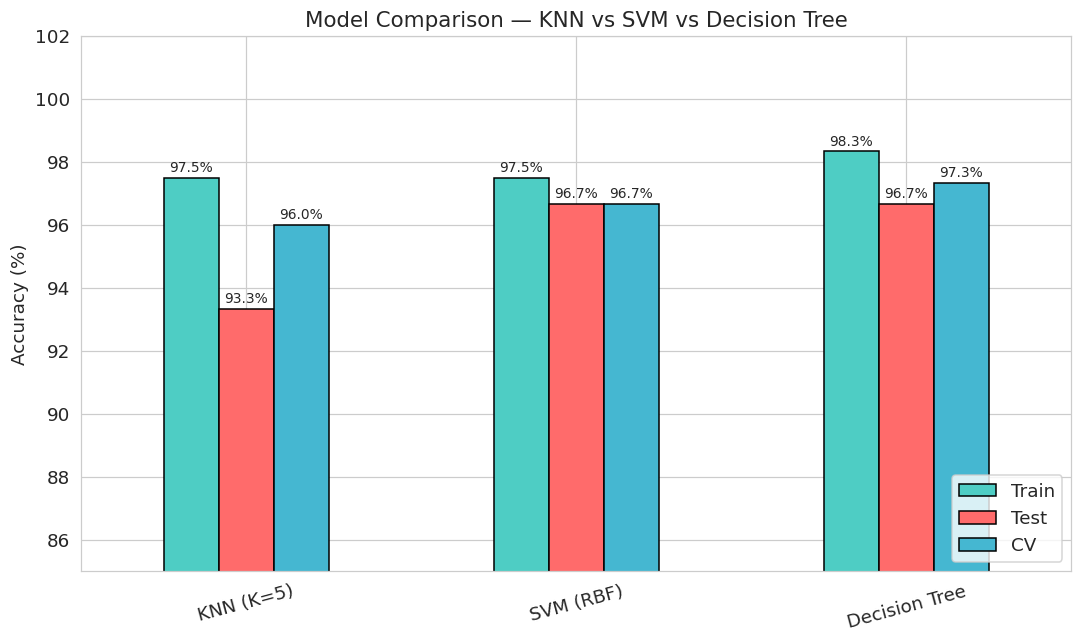

In [18]:
# ════════════════════════════════════════════
#  Model Comparison — All 3 on Iris
# ════════════════════════════════════════════

iris = load_iris()
X_all, y_all = iris.data, iris.target
X_all_s = StandardScaler().fit_transform(X_all)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all_s, y_all, test_size=0.2, random_state=42, stratify=y_all)

models = {
    'KNN (K=5)'       : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)'       : SVC(kernel='rbf', C=1, gamma='scale'),
    'Decision Tree'   : DecisionTreeClassifier(max_depth=3, random_state=42),
}

results = {}
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'CV (5-fold)':>12}")
print("─" * 58)
for name, model in models.items():
    model.fit(X_tr, y_tr)
    tr_acc = accuracy_score(y_tr, model.predict(X_tr))
    te_acc = accuracy_score(y_te, model.predict(X_te))
    cv     = cross_val_score(model, X_all_s, y_all, cv=5).mean()
    results[name] = {'Train': tr_acc, 'Test': te_acc, 'CV': cv}
    print(f"{name:<22} {tr_acc*100:>9.2f}% {te_acc*100:>9.2f}% {cv*100:>11.2f}%")

# ── Bar chart ──
df_res = pd.DataFrame(results).T
ax = df_res[['Train','Test','CV']].mul(100).plot(
    kind='bar', figsize=(10, 6), rot=15, edgecolor='black',
    color=['#4ECDC4','#FF6B6B','#45B7D1'])
plt.ylabel('Accuracy (%)'); plt.ylim(85, 102)
plt.title('Model Comparison — KNN vs SVM vs Decision Tree', fontsize=14)
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)
plt.tight_layout()
plt.show()


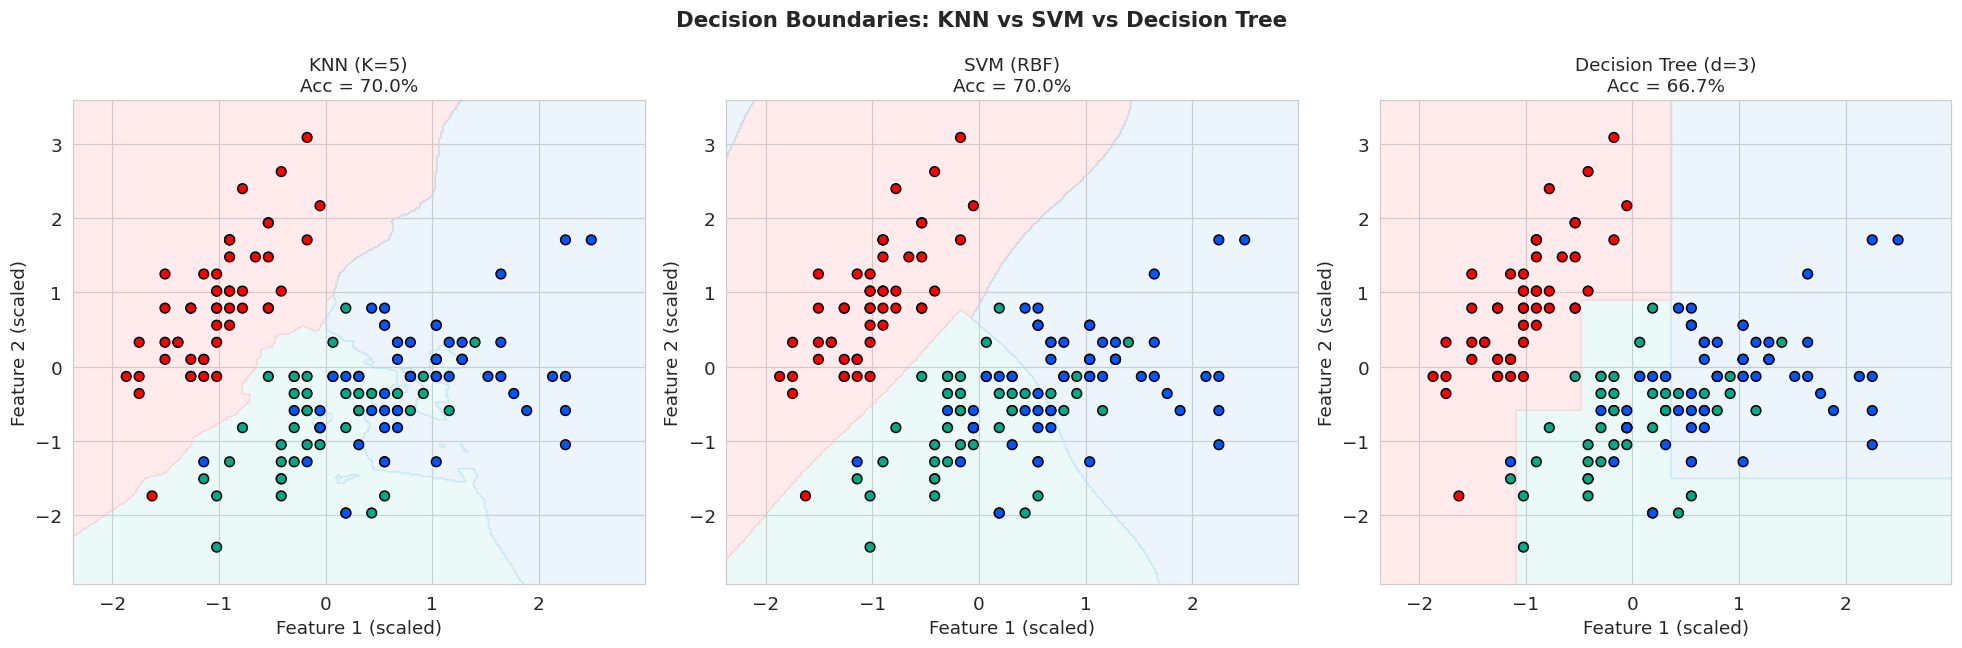

In [19]:
# ════════════════════════════════════════════
#  Model Comparison — Decision Boundaries (2D)
# ════════════════════════════════════════════

X2 = X_all_s[:, :2]
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y_all, test_size=0.2, random_state=42, stratify=y_all)

models_2d = {
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', C=1, gamma='scale'),
    'Decision Tree (d=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cmap_bg   = ListedColormap(['#FFB3B3','#B3EDEA','#B3D9F0'])
cmap_pts  = ListedColormap(['#FF0000','#00AA88','#0055FF'])

for ax, (name, model) in zip(axes, models_2d.items()):
    model.fit(X2_tr, y2_tr)
    acc = accuracy_score(y2_te, model.predict(X2_te))
    x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
    y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,300),
                         np.linspace(y_min,y_max,300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_bg)
    ax.scatter(X2[:,0], X2[:,1], c=y_all, cmap=cmap_pts, edgecolors='k', s=40)
    ax.set_title(f'{name}\nAcc = {acc*100:.1f}%', fontsize=12)
    ax.set_xlabel('Feature 1 (scaled)'); ax.set_ylabel('Feature 2 (scaled)')

plt.suptitle('Decision Boundaries: KNN vs SVM vs Decision Tree', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 📊 Quick Summary Table

| Property | KNN | SVM | Decision Tree |
|----------|-----|-----|---------------|
| **Training speed** | Instant (lazy) | Slow (large data) | Fast |
| **Prediction speed** | Slow O(n) | Fast | Very Fast |
| **Needs scaling?** | ✅ Yes | ✅ Yes | ❌ No |
| **Handles non-linear?** | ✅ Yes | ✅ (kernels) | ✅ Yes |
| **Interpretable?** | Partially | ❌ No | ✅ Very |
| **Overfitting risk** | High (K=1) | Low (margin) | High (deep trees) |
| **Best for** | Small, low-dim data | High-dim, complex | Explainability |


---
## 6. 🔥 Complex Tasks

> These tasks push your understanding beyond the basics. Try to solve them on your own before looking for hints!

---

### 🔴 Task 1 — Full ML Pipeline with Hyperparameter Tuning & Cross Validation

**Problem Statement:**  
Using the **Breast Cancer Wisconsin dataset**, build a complete end-to-end pipeline that:

1. Performs **Exploratory Data Analysis (EDA)** — class balance, feature distributions, correlation heatmap
2. Applies **feature selection** — keep only the top 10 most correlated features with the target
3. Trains **all 3 models** (KNN, SVM, Decision Tree) using **GridSearchCV** with 5-fold CV
4. Compares models using: Accuracy, Precision, Recall, F1-Score, and **ROC-AUC**
5. Plots **ROC curves** for all 3 models on the same graph
6. Identifies the **best model** and explains why

**Hints:**
- Use `SVC(probability=True)` to get probability scores for ROC curves
- Use `roc_curve` and `auc` from `sklearn.metrics`
- Think about which metric matters most for cancer detection (Recall? Precision?)

---

### 🔴 Task 2 — Custom Dataset + Ensemble Comparison

**Problem Statement:**  
Generate a **complex synthetic dataset** and explore the limits of each model:

1. Use `make_classification(n_samples=2000, n_features=20, n_informative=10, n_redundant=5, n_clusters_per_class=3, random_state=42)`
2. Implement a **custom cross-validation loop** (do NOT use `cross_val_score`) — manually split data into 5 folds, train and evaluate each model, and report mean ± std accuracy
3. Add **feature importance analysis** using permutation importance (`sklearn.inspection.permutation_importance`) for all 3 models
4. Experiment with **Decision Tree pruning** using `cost_complexity_pruning_path` — plot the relationship between `ccp_alpha` and accuracy
5. Build a **simple Voting Classifier** combining all 3 models and compare its performance against individual models
6. Create a final **publication-quality figure** showing all results

**Hints:**
- `from sklearn.ensemble import VotingClassifier`
- `from sklearn.inspection import permutation_importance`
- Use `dt.cost_complexity_pruning_path(X_train, y_train)` to get alphas

---

> 💡 **Tip:** Start with Task 1 as it consolidates everything from this notebook. Task 2 introduces concepts you'll see in Week 4 (Ensembles)!


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  YOUR SOLUTION — Task 1
# ─────────────────────────────────────────────────────────────────────────────

# Write your Task 1 solution here 👇



In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  YOUR SOLUTION — Task 2
# ─────────────────────────────────────────────────────────────────────────────

# Write your Task 2 solution here 👇

